Tham khảo:

https://www.youtube.com/watch?v=Dl5lPdoCXi8

https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html

https://www.youtube.com/watch?v=wG55VcO8hZ0&t=1374s

https://en.wikipedia.org/wiki/Canny_edge_detector

# Canny detection

Bộ dò cạnh Canny (Canny edge detector) là một toán tử phát hiện cạnh sử dụng thuật toán nhiều giai đoạn để phát hiện một loạt các cạnh trong hình ảnh. Nó được phát triển bởi John F. Canny vào năm 1986. Canny cũng đã đưa ra một lý thuyết tính toán về phát hiện cạnh, giải thích tại sao kỹ thuật này hoạt động hiệu quả.

# Thuật toán phát hiện cạnh Canny

Thuật toán phát hiện cạnh Canny có thể được chia thành 5 bước như sau:

1. **Làm mịn hình ảnh bằng bộ lọc Gaussian**  
   Áp dụng bộ lọc Gaussian để làm mịn hình ảnh nhằm loại bỏ nhiễu.

2. **Tính gradient cường độ của hình ảnh**  
   Tính gradient cường độ để xác định sự thay đổi giá trị pixel trong hình ảnh.

3. **Ngưỡng độ lớn gradient**  
   Áp dụng ngưỡng độ lớn gradient hoặc loại bỏ các phản hồi sai để loại bỏ những kết quả không mong muốn trong việc phát hiện cạnh.

4. **Áp dụng ngưỡng kép (Double Threshold)**  
   Xác định các cạnh tiềm năng bằng cách áp dụng hai mức ngưỡng:
   - Ngưỡng cao: Các cạnh mạnh.
   - Ngưỡng thấp: Các cạnh yếu.

5. **Theo dõi cạnh bằng kỹ thuật hysteresis**  
   Hoàn tất việc phát hiện các cạnh bằng cách:
   - Giữ lại các cạnh yếu nếu chúng kết nối với các cạnh mạnh.
   - Loại bỏ các cạnh yếu không liên kết với cạnh mạnh.



## Tính gradient cường độ của hình ảnh
Một cạnh trong hình ảnh có thể hướng theo nhiều hướng khác nhau, vì vậy thuật toán Canny sử dụng bốn bộ lọc để phát hiện các cạnh **ngang**, **dọc** và **chéo** trong hình ảnh đã được làm mờ.

Toán tử phát hiện cạnh (chẳng hạn như **Roberts**, **Prewitt**, hoặc **Sobel**) trả về giá trị cho **đạo hàm bậc nhất** theo:
- **Hướng ngang**: \(G_x\)
- **Hướng dọc**: \(G_y\)

Từ đó, **gradient cạnh** và **hướng cạnh** có thể được xác định như sau:

- **Gradient \(G\)** có thể được tính bằng hàm `hypot`:  
    $$ G = \sqrt{G_x^2 + G_y^2} $$

- **Góc hướng cạnh** được tính bằng hàm `atan2`:  
  $$ \theta = \text{atan2}(G_y, G_x)$$

## Làm tròn góc hướng
Góc hướng của cạnh (\(\theta\)) được làm tròn về một trong bốn giá trị đại diện cho các hướng:
- **0°**: Ngang.
- **45°**: Chéo phải lên.
- **90°**: Dọc.
- **135°**: Chéo phải xuống.

Ví dụ:
- Góc \(\theta\) trong khoảng \([0°, 22.5°]\) hoặc \([157.5°, 180°]\) được ánh xạ thành **0°**.
- Các khoảng tương tự được xác định cho các góc **45°**, **90°**, và **135°**.

Hướng gradient luôn vuông góc với các cạnh. Nó được làm tròn về một trong bốn góc đại diện cho các hướng dọc, ngang và hai hướng chéo.


## Gradient là gì?

Gradient là một khái niệm trong toán học và xử lý ảnh, dùng để biểu diễn sự thay đổi của một đại lượng trong không gian. Trong ngữ cảnh của hình ảnh, **gradient** mô tả **mức độ thay đổi cường độ sáng** (intensity) giữa các pixel lân cận. Nó là một công cụ quan trọng để phát hiện các cạnh (edges) trong hình ảnh.

---

### **Ý nghĩa của Gradient trong hình ảnh**

1. **Cường độ Gradient (Gradient Magnitude)**:
    - Là độ lớn của sự thay đổi cường độ sáng tại một pixel.
    - Nếu cường độ gradient lớn, có nghĩa là tại đó có sự thay đổi mạnh về màu sắc hoặc sáng tối (thường là một cạnh).
    - Công thức tính:
      $$
      G = \sqrt{G_x^2 + G_y^2}
      $$
      Trong đó:
      - \( G_x \): Sự thay đổi theo chiều ngang (trục x).
      - \( G_y \): Sự thay đổi theo chiều dọc (trục y).

2. **Hướng Gradient (Gradient Direction)**:
    - Là hướng của sự thay đổi mạnh nhất trong cường độ sáng.
    - Công thức tính:
      $$
      \theta = \arctan\left(\frac{G_y}{G_x}\right)
      $$
    - Hướng gradient luôn vuông góc với cạnh trong hình ảnh.

---

### **Ứng dụng của Gradient**

1. **Phát hiện cạnh (Edge Detection)**:
    - Gradient được sử dụng để xác định vị trí các cạnh trong hình ảnh (những nơi có sự thay đổi mạnh về cường độ sáng).
    - Ví dụ: Thuật toán Canny, Sobel, Prewitt.

2. **Phân tích hình ảnh**:
    - Gradient giúp hiểu rõ hơn về cấu trúc của hình ảnh, như hình dạng, biên, và chi tiết.

3. **Làm nổi bật các đặc trưng (Feature Extraction)**:
    - Gradient được sử dụng trong các mô hình học máy hoặc học sâu để trích xuất đặc trưng từ hình ảnh.

---

### **Ví dụ Minh Họa**

Giả sử bạn có một hình ảnh grayscale:

- **Pixel 1**: Cường độ sáng = 10.
- **Pixel 2**: Cường độ sáng = 50.
- Gradient giữa Pixel 1 và Pixel 2:
  $$
  |50 - 10| = 40
  $$
  Điều này cho thấy sự thay đổi mạnh giữa hai pixel, thường là vị trí một cạnh.


In [21]:
import cv2
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [22]:
img = cv2.imread('Image/messi.png') # BGR

In [23]:
img_rgb =cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

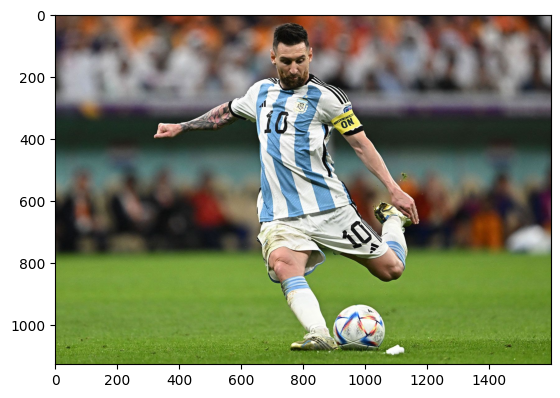

In [24]:
plt.imshow(img_rgb)

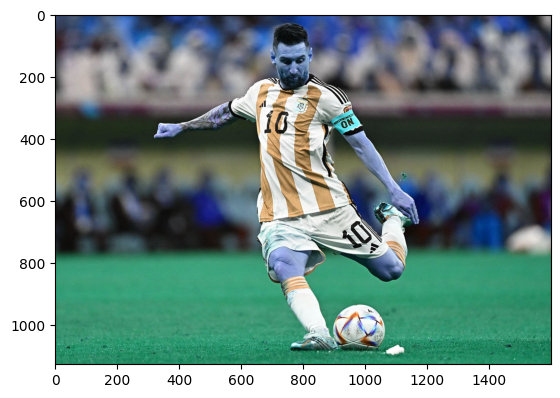

In [5]:
plt.imshow(img)

In [6]:
edges = cv2.Canny(image=img, threshold1=127, threshold2=127)

## threshold1=127 và threshold2=127:
- Hai tham số ngưỡng này được sử dụng trong bước áp dụng ngưỡng kép (double threshold) của thuật toán Canny để phân loại các pixel:
- threshold1 (Lower threshold): Giá trị ngưỡng thấp. Pixel có gradient nhỏ hơn giá trị này sẽ bị bỏ qua (coi như không phải cạnh).
- threshold2 (Upper threshold): Giá trị ngưỡng cao. Pixel có gradient lớn hơn giá trị này sẽ được coi là cạnh mạnh.
Các pixel nằm giữa hai ngưỡng sẽ chỉ được coi là cạnh nếu chúng liên kết với các cạnh mạnh.

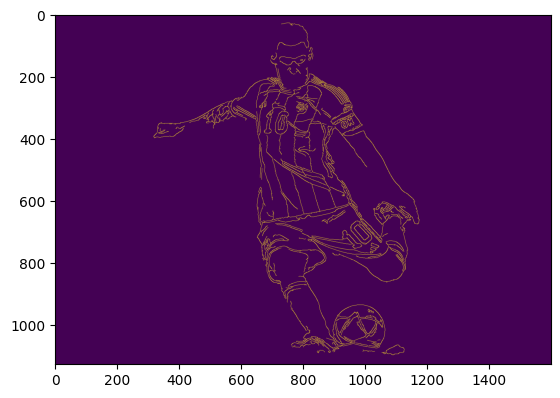

In [26]:
plt.imshow(edges)

In [27]:
edges = cv2.Canny(image=img, threshold1=0, threshold2=255)

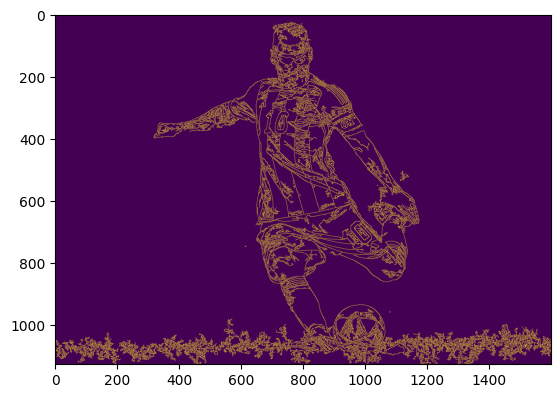

In [9]:
plt.imshow(edges)

# Choosing Thresholds

## 📌 Tại sao lại lấy trung vị?

### 🔹 1. **Trung vị ít bị ảnh hưởng bởi nhiễu (outliers)**

- **Trung bình (mean)** dễ bị ảnh hưởng bởi các điểm bất thường (**outliers**). Ví dụ, nếu có một số điểm ảnh rất sáng hoặc rất tối trong ảnh, trung bình có thể bị lệch.
- **Trung vị (median)** lấy giá trị ở giữa tập dữ liệu nên ít bị ảnh hưởng hơn. Điều này giúp xác định ngưỡng đáng tin cậy hơn.

### 🔹 2. **Phù hợp với dữ liệu không đối xứng (skewed data)**

- Nếu dữ liệu có phân bố không đều (ví dụ: nhiều điểm ảnh tối và một số ít điểm sáng), trung bình có thể không phản ánh đúng đặc điểm chung của dữ liệu.
- Trung vị luôn nằm ở giữa tập dữ liệu, giúp đảm bảo rằng giá trị ngưỡng không bị lệch quá nhiều về phía cao hoặc thấp.

### 🔹 3. **Ứng dụng trong xử lý ảnh (Image Processing)**

Trong các thuật toán như **adaptive thresholding** hoặc **Canny edge detection**, trung vị được sử dụng để xác định mức sáng chung của ảnh và từ đó đặt ngưỡng phù hợp để phân biệt vùng sáng - tối. Điều này giúp tăng độ chính xác khi phát hiện biên hoặc phân đoạn ảnh.

> 💡 **Kết luận**: Dùng **trung vị** thay vì trung bình giúp xác định ngưỡng ổn định hơn, giảm ảnh hưởng của nhiễu và phù hợp với dữ liệu có phân bố không đồng đều.


In [10]:
med_val = np.median(img) 

In [11]:
# Lower bound is either 0 or 70% of the median value, whicever is higher
lower = int(max(0, 0.7* med_val))

In [12]:
# Upper bound is either 255 or 30% above the median value, whichever is lower
upper = int(min(255,1.3 * med_val))

In [28]:
edges = cv2.Canny(image=img, threshold1=lower , threshold2=upper)

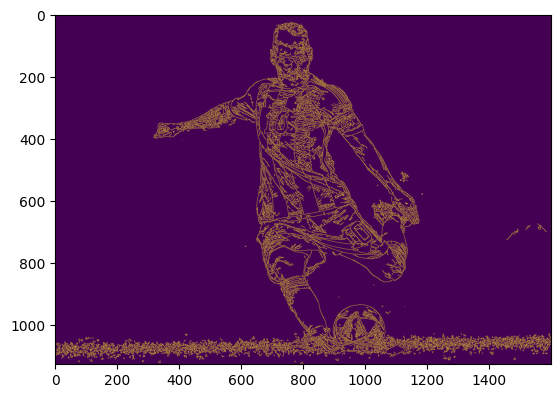

In [29]:
plt.imshow(edges)

# Blur first

In [30]:
blurred_img = cv2.blur(img,ksize=(5,5))

In [31]:
edges = cv2.Canny(image=blurred_img, threshold1=lower , threshold2=upper)

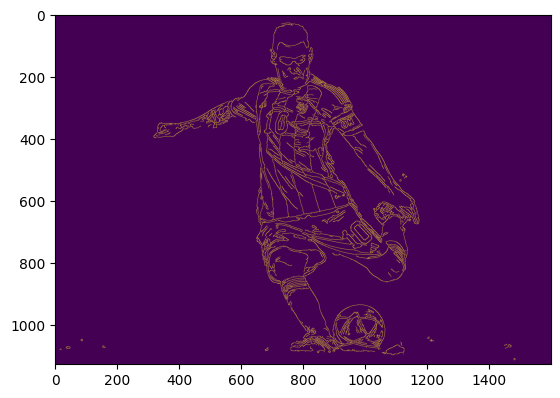

In [32]:
plt.imshow(edges)

In [18]:
lower

72

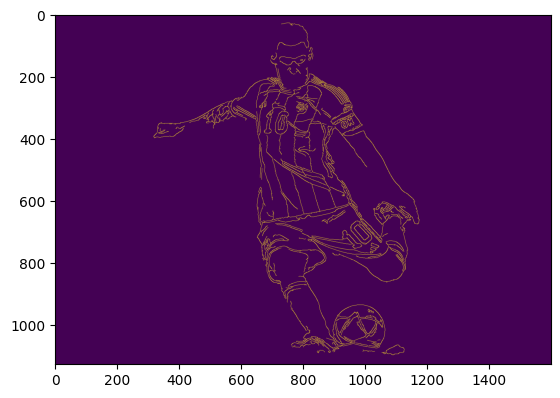

In [33]:
edges = cv2.Canny(image=blurred_img, threshold1=lower , threshold2=upper+100)
plt.imshow(edges)